In [1]:
!pip install dlib opencv-python pandas matplotlib

In [2]:
import os
import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/facial_dataset/facial_dataset"

print("Dataset exists:", os.path.exists(DATASET_PATH))

print("\nFolders:")
print(os.listdir(DATASET_PATH))

Dataset exists: True

Folders:
['Ahmad', 'Sara', 'Ali']


In [5]:
for person in os.listdir(DATASET_PATH):

    person_path = os.path.join(DATASET_PATH, person)

    if os.path.isdir(person_path):

        images = os.listdir(person_path)

        print(person, ":", len(images), "images")
        print(images)
        print()

Ahmad : 10 images
['ahmad4.jpg', 'ahmad9.jpg', 'ahmad2.jpg', 'ahmad8.jpg', 'ahmad6.jpg', 'ahmad10.jpg', 'ahmad7.jpg', 'ahmad5.jpg', 'ahmad3.jpg', 'ahmad1.jpg']

Sara : 10 images
['sara2.jpg', 'sara9.jpg', 'sara3.jpg', 'sara6.jpg', 'sara8.jpg', 'sara1.jpg', 'sara10.jpg', 'sara7.jpg', 'sara5.jpg', 'sara4.jpg']

Ali : 10 images
['ali9.jpg', 'ali8.jpg', 'ali2.jpg', 'ali6.jpg', 'ali1.jpg', 'ali5.jpg', 'ali4.jpg', 'ali3.jpg', 'ali10.jpg', 'ali7.jpg']



In [6]:
!wget -q https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2

In [7]:
detector = dlib.get_frontal_face_detector()

predictor = dlib.shape_predictor(
    "/content/shape_predictor_68_face_landmarks.dat"
)

print("Dlib detector loaded successfully!")
print("68-landmark predictor loaded successfully!")

Dlib detector loaded successfully!
68-landmark predictor loaded successfully!


In [8]:
person_names = ["Ahmad", "Sara", "Ali"]

class_mapping = {
    "Ahmad": 0,
    "Sara": 1,
    "Ali": 2
}

print("Class Mapping:")

for person, class_id in class_mapping.items():
    print(person, "-> Class", class_id)

Class Mapping:
Ahmad -> Class 0
Sara -> Class 1
Ali -> Class 2


In [9]:
feature_names = []

for i in range(1, 69):
    feature_names.append(f"x{i}")
    feature_names.append(f"y{i}")

feature_names.append("Class")

print("Number of columns:", len(feature_names))
print(feature_names)

Number of columns: 137
['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'x22', 'y22', 'x23', 'y23', 'x24', 'y24', 'x25', 'y25', 'x26', 'y26', 'x27', 'y27', 'x28', 'y28', 'x29', 'y29', 'x30', 'y30', 'x31', 'y31', 'x32', 'y32', 'x33', 'y33', 'x34', 'y34', 'x35', 'y35', 'x36', 'y36', 'x37', 'y37', 'x38', 'y38', 'x39', 'y39', 'x40', 'y40', 'x41', 'y41', 'x42', 'y42', 'x43', 'y43', 'x44', 'y44', 'x45', 'y45', 'x46', 'y46', 'x47', 'y47', 'x48', 'y48', 'x49', 'y49', 'x50', 'y50', 'x51', 'y51', 'x52', 'y52', 'x53', 'y53', 'x54', 'y54', 'x55', 'y55', 'x56', 'y56', 'x57', 'y57', 'x58', 'y58', 'x59', 'y59', 'x60', 'y60', 'x61', 'y61', 'x62', 'y62', 'x63', 'y63', 'x64', 'y64', 'x65', 'y65', 'x66', 'y66', 'x67', 'y67', 'x68', 'y68', 'Class']


In [10]:
OUTPUT_PATH = "/content/drive/MyDrive/facial_landmark_output"

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Output folder created:")
print(OUTPUT_PATH)

Output folder created:
/content/drive/MyDrive/facial_landmark_output


In [11]:
test_image_path = "/content/drive/MyDrive/facial_dataset/facial_dataset/Ahmad/ahmad1.jpg"

image = cv2.imread(test_image_path)

print("Image loaded:", image is not None)

rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

faces = detector(rgb_image)

print("Number of faces detected:", len(faces))

Image loaded: True
Number of faces detected: 1


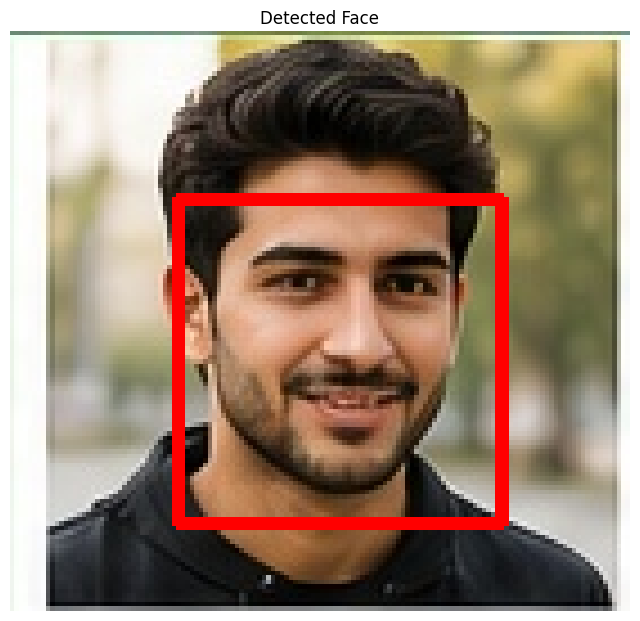

In [12]:
image_with_face = rgb_image.copy()

for face in faces:

    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    cv2.rectangle(
        image_with_face,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8, 8))
plt.imshow(image_with_face)
plt.axis("off")
plt.title("Detected Face")
plt.show()

In [13]:
face = faces[0]

landmarks = predictor(rgb_image, face)

print("Number of landmarks:", landmarks.num_parts)

Number of landmarks: 68


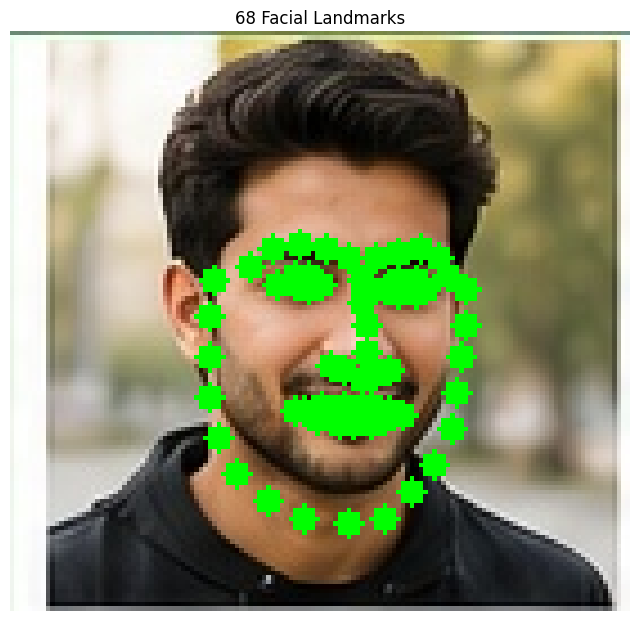

In [14]:
landmark_image = rgb_image.copy()

for i in range(68):

    x = landmarks.part(i).x
    y = landmarks.part(i).y

    cv2.circle(
        landmark_image,
        (x, y),
        3,
        (0, 255, 0),
        -1
    )

plt.figure(figsize=(8, 8))
plt.imshow(landmark_image)
plt.axis("off")
plt.title("68 Facial Landmarks")
plt.show()

In [15]:
features = []

for i in range(68):

    x = landmarks.part(i).x
    y = landmarks.part(i).y

    features.append(x)
    features.append(y)

print("Number of features:", len(features))
print(features)

Number of features: 136
[45, 55, 44, 63, 44, 72, 44, 81, 46, 90, 50, 98, 57, 104, 65, 108, 75, 109, 83, 108, 89, 102, 94, 96, 98, 88, 99, 80, 100, 72, 101, 65, 101, 57, 53, 52, 58, 48, 64, 47, 70, 48, 75, 50, 81, 50, 86, 49, 91, 48, 95, 50, 97, 54, 78, 55, 78, 60, 79, 65, 79, 71, 71, 74, 74, 75, 78, 77, 81, 76, 84, 75, 59, 56, 63, 54, 66, 54, 69, 56, 66, 57, 63, 56, 83, 57, 86, 55, 90, 55, 92, 57, 90, 58, 86, 58, 63, 84, 69, 83, 74, 83, 77, 84, 80, 83, 84, 84, 87, 85, 83, 86, 80, 87, 76, 87, 73, 87, 68, 86, 65, 84, 73, 86, 77, 86, 80, 86, 85, 85, 80, 84, 76, 84, 73, 84]


In [16]:
class_id = class_mapping["Ahmad"]

features_with_class = features + [class_id]

print("Number of values:", len(features_with_class))
print("Class:", class_id)

Number of values: 137
Class: 0


In [17]:
people = {
    "Ahmad": 0,
    "Sara": 1,
    "Ali": 2
}

print("Class mapping:")

for person, class_label in people.items():
    print(person, "→ Class", class_label)

Class mapping:
Ahmad → Class 0
Sara → Class 1
Ali → Class 2


In [18]:
OUTPUT_PATH = "/content/drive/MyDrive/facial_landmark_output"

ANNOTATED_PATH = os.path.join(
    OUTPUT_PATH,
    "annotated_images"
)

os.makedirs(ANNOTATED_PATH, exist_ok=True)

for person in people:
    os.makedirs(
        os.path.join(ANNOTATED_PATH, person),
        exist_ok=True
    )

print("Output folders created!")
print(OUTPUT_PATH)

Output folders created!
/content/drive/MyDrive/facial_landmark_output


In [19]:
all_data = []

successful_images = 0
failed_images = 0

for person_name, class_label in people.items():

    print("\n================================")
    print("Person:", person_name)
    print("Class:", class_label)
    print("================================")

    person_folder = os.path.join(
        DATASET_PATH,
        person_name
    )

    image_files = os.listdir(person_folder)

    for image_file in sorted(image_files):

        image_path = os.path.join(
            person_folder,
            image_file
        )

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            print("ERROR:", image_file)
            failed_images += 1
            continue

        # Convert to grayscale
        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )

        # Detect faces
        faces = detector(gray)

        if len(faces) == 0:

            print("NO FACE:", image_file)

            failed_images += 1
            continue

        # If more than one face is detected,
        # choose the largest face.
        face = max(
            faces,
            key=lambda rect: rect.width() * rect.height()
        )

        # Detect the 68 landmarks
        landmarks = predictor(
            gray,
            face
        )

        # Store x,y coordinates
        features = []

        for i in range(68):

            x = landmarks.part(i).x
            y = landmarks.part(i).y

            features.append(x)
            features.append(y)

        # Check that we have exactly 136 features
        if len(features) != 136:

            print(
                "ERROR: Wrong number of features:",
                image_file
            )

            failed_images += 1
            continue

        # Add class label
        features.append(class_label)

        # Add this image to the dataset
        all_data.append(features)

        successful_images += 1

        # Draw face rectangle
        cv2.rectangle(
            image,
            (face.left(), face.top()),
            (face.right(), face.bottom()),
            (0, 255, 0),
            2
        )

        # Draw all 68 landmarks
        for i in range(68):

            x = landmarks.part(i).x
            y = landmarks.part(i).y

            cv2.circle(
                image,
                (x, y),
                2,
                (0, 0, 255),
                -1
            )

            # Optional: show landmark number
            cv2.putText(
                image,
                str(i),
                (x + 3, y - 3),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.3,
                (255, 0, 0),
                1
            )

        # Write person/class information
        cv2.putText(
            image,
            f"Person: {person_name} | Class: {class_label}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        # Save annotated image
        output_image_path = os.path.join(
            ANNOTATED_PATH,
            person_name,
            image_file
        )

        cv2.imwrite(
            output_image_path,
            image
        )

        print("Processed:", image_file)


print("\n================================")
print("PROCESSING FINISHED")
print("================================")

print("Successful:", successful_images)
print("Failed:", failed_images)

print(
    "Total feature values:",
    successful_images * 136
)


Person: Ahmad
Class: 0
Processed: ahmad1.jpg
Processed: ahmad10.jpg
Processed: ahmad2.jpg
Processed: ahmad3.jpg
Processed: ahmad4.jpg
Processed: ahmad5.jpg
Processed: ahmad6.jpg
Processed: ahmad7.jpg
Processed: ahmad8.jpg
Processed: ahmad9.jpg

Person: Sara
Class: 1
Processed: sara1.jpg
Processed: sara10.jpg
Processed: sara2.jpg
Processed: sara3.jpg
Processed: sara4.jpg
Processed: sara5.jpg
Processed: sara6.jpg
Processed: sara7.jpg
Processed: sara8.jpg
Processed: sara9.jpg

Person: Ali
Class: 2
Processed: ali1.jpg
Processed: ali10.jpg
Processed: ali2.jpg
Processed: ali3.jpg
Processed: ali4.jpg
Processed: ali5.jpg
Processed: ali6.jpg
Processed: ali7.jpg
Processed: ali8.jpg
Processed: ali9.jpg

PROCESSING FINISHED
Successful: 30
Failed: 0
Total feature values: 4080


In [20]:
df = pd.DataFrame(
    all_data,
    columns=feature_names
)

print("Dataset shape:")
print(df.shape)

display(df.head())

Dataset shape:
(30, 137)


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,y64,x65,y65,x66,y66,x67,y67,x68,y68,Class
0,44,54,44,63,43,72,43,82,45,91,...,88,85,86,79,85,75,86,72,86,0
1,45,58,45,64,44,70,45,77,46,83,...,82,72,83,64,85,61,85,58,85,0
2,45,51,45,59,45,66,45,74,47,81,...,77,83,78,76,81,72,81,69,80,0
3,44,59,44,68,43,77,45,86,48,95,...,88,85,90,76,94,72,95,68,94,0
4,40,57,40,64,41,72,42,79,44,86,...,82,76,82,71,82,67,83,64,82,0


In [21]:
feature_columns = [
    col for col in df.columns
    if col != "Class"
]

print("Number of landmark features:", len(feature_columns))
print("Number of classes:", df["Class"].nunique())
print("Number of samples:", len(df))

Number of landmark features: 136
Number of classes: 3
Number of samples: 30


In [22]:
print("Number of samples per class:")

print(
    df["Class"]
    .value_counts()
    .sort_index()
)

Number of samples per class:
Class
0    10
1    10
2    10
Name: count, dtype: int64


In [23]:
CSV_PATH = os.path.join(
    OUTPUT_PATH,
    "facial_landmarks.csv"
)

df.to_csv(
    CSV_PATH,
    index=False
)

print("CSV CREATED SUCCESSFULLY!")
print()
print("File location:")
print(CSV_PATH)

CSV CREATED SUCCESSFULLY!

File location:
/content/drive/MyDrive/facial_landmark_output/facial_landmarks.csv


In [24]:
df_check = pd.read_csv(CSV_PATH)

print("CSV loaded successfully!")
print("Shape:", df_check.shape)

display(df_check.head())

CSV loaded successfully!
Shape: (30, 137)


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,y64,x65,y65,x66,y66,x67,y67,x68,y68,Class
0,44,54,44,63,43,72,43,82,45,91,...,88,85,86,79,85,75,86,72,86,0
1,45,58,45,64,44,70,45,77,46,83,...,82,72,83,64,85,61,85,58,85,0
2,45,51,45,59,45,66,45,74,47,81,...,77,83,78,76,81,72,81,69,80,0
3,44,59,44,68,43,77,45,86,48,95,...,88,85,90,76,94,72,95,68,94,0
4,40,57,40,64,41,72,42,79,44,86,...,82,76,82,71,82,67,83,64,82,0


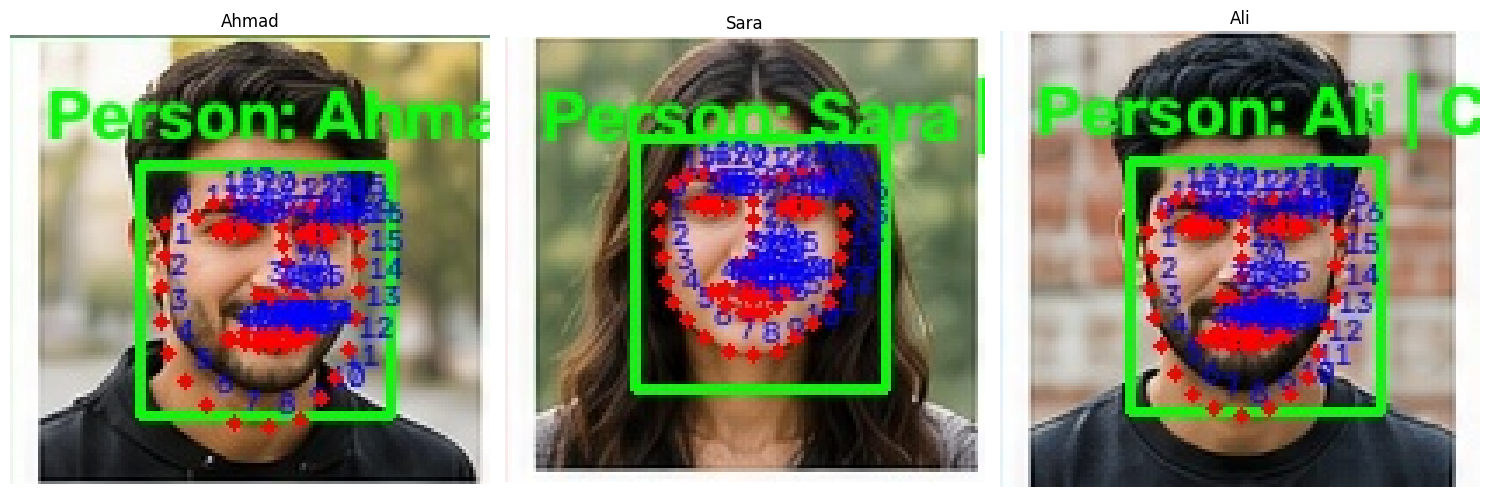

In [25]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for ax, person in zip(axes, people.keys()):

    person_folder = os.path.join(
        ANNOTATED_PATH,
        person
    )

    image_files = sorted(
        os.listdir(person_folder)
    )

    if len(image_files) == 0:
        ax.set_title(person + " - No image")
        ax.axis("off")
        continue

    image_path = os.path.join(
        person_folder,
        image_files[0]
    )

    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image_rgb)
    ax.set_title(person)
    ax.axis("off")

plt.tight_layout()
plt.show()

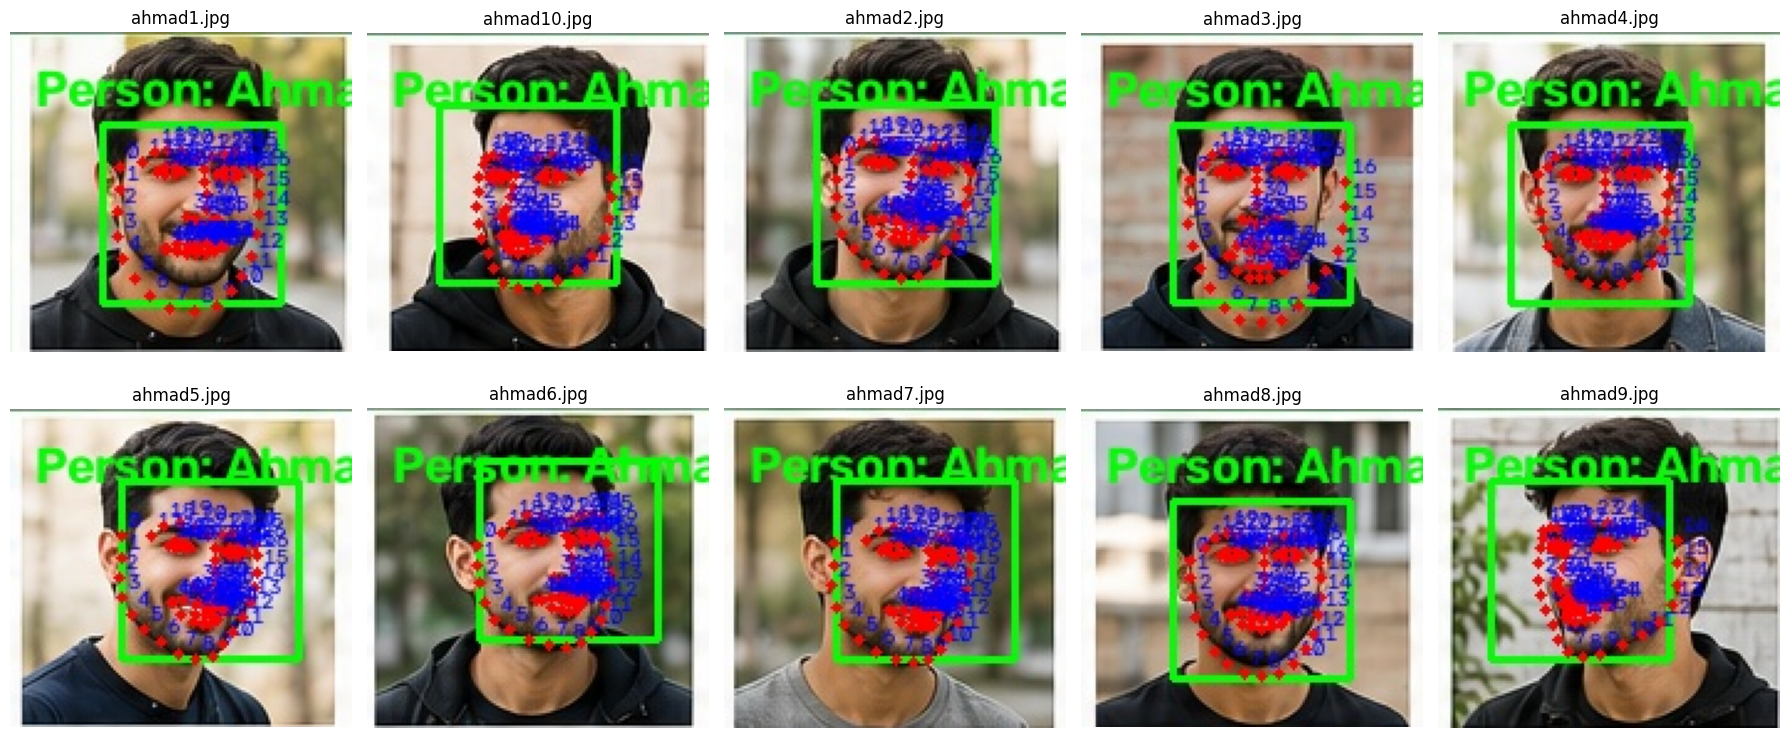

In [26]:
person = "Ahmad"

person_folder = os.path.join(
    ANNOTATED_PATH,
    person
)

image_files = sorted(
    os.listdir(person_folder)
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, image_file in zip(
    axes.ravel(),
    image_files[:10]
):

    image_path = os.path.join(
        person_folder,
        image_file
    )

    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image_rgb)
    ax.set_title(image_file)
    ax.axis("off")

plt.tight_layout()
plt.show()

Number of saved landmark images: 30


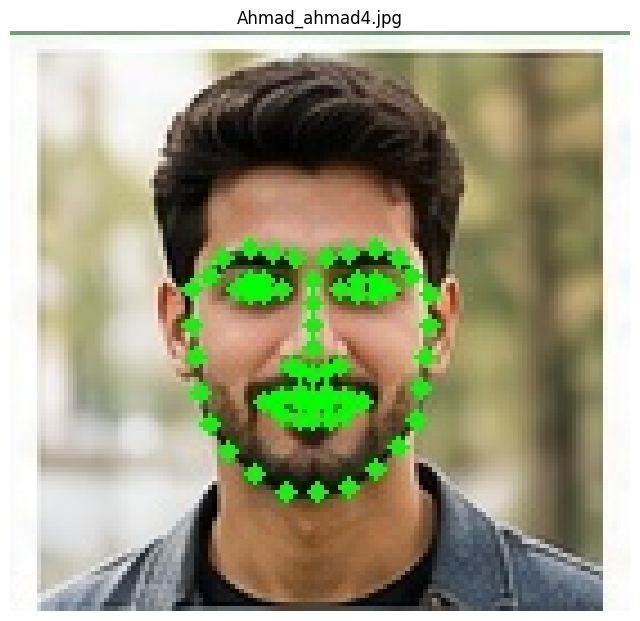

In [27]:
saved_images = [
    f for f in os.listdir(OUTPUT_PATH)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

print("Number of saved landmark images:", len(saved_images))

sample_path = os.path.join(
    OUTPUT_PATH,
    saved_images[0]
)

sample = cv2.imread(sample_path)
sample = cv2.cvtColor(
    sample,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 8))
plt.imshow(sample)
plt.axis("off")
plt.title(saved_images[0])
plt.show()

In [28]:
# Task 2
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [30]:
CSV_PATH = "/content/drive/MyDrive/facial_landmark_output/facial_landmarks.csv"

MODEL_PATH = "/content/shape_predictor_68_face_landmarks.dat"

print("CSV exists:", os.path.exists(CSV_PATH))
print("Dlib model exists:", os.path.exists(MODEL_PATH))

CSV exists: True
Dlib model exists: True


In [31]:
df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (30, 137)


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,y64,x65,y65,x66,y66,x67,y67,x68,y68,Class
0,44,54,44,63,43,72,43,82,45,91,...,88,85,86,79,85,75,86,72,86,0
1,45,58,45,64,44,70,45,77,46,83,...,82,72,83,64,85,61,85,58,85,0
2,45,51,45,59,45,66,45,74,47,81,...,77,83,78,76,81,72,81,69,80,0
3,44,59,44,68,43,77,45,86,48,95,...,88,85,90,76,94,72,95,68,94,0
4,40,57,40,64,41,72,42,79,44,86,...,82,76,82,71,82,67,83,64,82,0


In [32]:
print("Column names:")
print(df.columns.tolist())

print("\nNumber of samples:", len(df))

print("\nNumber of columns:", len(df.columns))

print("\nClass distribution:")
print(df["Class"].value_counts().sort_index())

Column names:
['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'x22', 'y22', 'x23', 'y23', 'x24', 'y24', 'x25', 'y25', 'x26', 'y26', 'x27', 'y27', 'x28', 'y28', 'x29', 'y29', 'x30', 'y30', 'x31', 'y31', 'x32', 'y32', 'x33', 'y33', 'x34', 'y34', 'x35', 'y35', 'x36', 'y36', 'x37', 'y37', 'x38', 'y38', 'x39', 'y39', 'x40', 'y40', 'x41', 'y41', 'x42', 'y42', 'x43', 'y43', 'x44', 'y44', 'x45', 'y45', 'x46', 'y46', 'x47', 'y47', 'x48', 'y48', 'x49', 'y49', 'x50', 'y50', 'x51', 'y51', 'x52', 'y52', 'x53', 'y53', 'x54', 'y54', 'x55', 'y55', 'x56', 'y56', 'x57', 'y57', 'x58', 'y58', 'x59', 'y59', 'x60', 'y60', 'x61', 'y61', 'x62', 'y62', 'x63', 'y63', 'x64', 'y64', 'x65', 'y65', 'x66', 'y66', 'x67', 'y67', 'x68', 'y68', 'Class']

Number of samples: 30

Number of columns:

In [33]:
# Seperate X and Y
X = df.drop("Class", axis=1)

y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 136)
y shape: (30,)


In [34]:
class_names = {
    0: "Ahmad",
    1: "Sara",
    2: "Ali"
}

print(class_names)

{0: 'Ahmad', 1: 'Sara', 2: 'Ali'}


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Scaling completed!
Training shape: (24, 136)
Testing shape: (6, 136)


In [37]:
perceptron = Perceptron(
    max_iter=2000,
    eta0=0.01,
    random_state=42,
    tol=1e-3
)

print("Perceptron created!")

Perceptron created!


In [38]:
perceptron.fit(
    X_train_scaled,
    y_train
)

print("Perceptron training completed!")

Perceptron training completed!


In [39]:
y_pred = perceptron.predict(
    X_test_scaled
)

print("Predictions:")
print(y_pred)

print("\nActual:")
print(y_test.to_numpy())

Predictions:
[1 1 2 1 1 1]

Actual:
[2 1 2 0 1 0]


In [40]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(
    "Accuracy percentage:",
    accuracy * 100,
    "%"
)

Accuracy: 0.5
Accuracy percentage: 50.0 %


In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[0 2 0]
 [0 2 0]
 [0 1 1]]


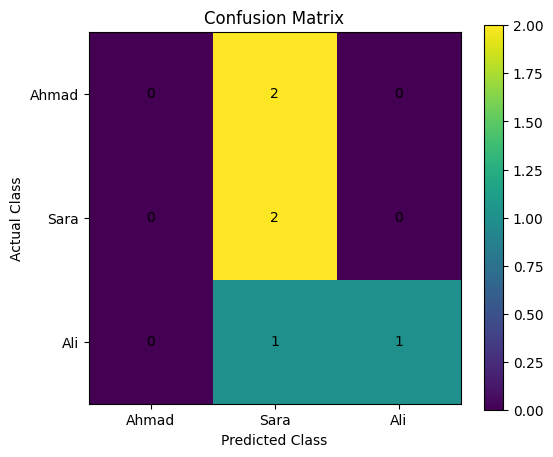

In [42]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.xticks(
    [0, 1, 2],
    ["Ahmad", "Sara", "Ali"]
)

plt.yticks(
    [0, 1, 2],
    ["Ahmad", "Sara", "Ali"]
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [43]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Ahmad",
        "Sara",
        "Ali"
    ],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       Ahmad       0.00      0.00      0.00         2
        Sara       0.40      1.00      0.57         2
         Ali       1.00      0.50      0.67         2

    accuracy                           0.50         6
   macro avg       0.47      0.50      0.41         6
weighted avg       0.47      0.50      0.41         6



In [44]:
print("==========================================")
print("PERCEPTRON MODEL EVALUATION")
print("==========================================")

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

print("==========================================")

PERCEPTRON MODEL EVALUATION
Accuracy: 50.00%

Confusion Matrix:
[[0 2 0]
 [0 2 0]
 [0 1 1]]

Classification Report:
              precision    recall  f1-score   support

       Ahmad       0.00      0.00      0.00         2
        Sara       0.40      1.00      0.57         2
         Ali       1.00      0.50      0.67         2

    accuracy                           0.50         6
   macro avg       0.47      0.50      0.41         6
weighted avg       0.47      0.50      0.41         6



In [45]:
detector = dlib.get_frontal_face_detector()

predictor = dlib.shape_predictor(
    MODEL_PATH
)

print("Dlib detector ready!")

Dlib detector ready!


In [46]:
from google.colab import files

uploaded = files.upload()

Saving sara1.jpg to sara1.jpg


In [47]:
uploaded_filename = list(uploaded.keys())[0]

image_path = "/content/" + uploaded_filename

print("Testing image:")
print(image_path)

Testing image:
/content/sara1.jpg


In [48]:
# EAR=2∣∣P1−P4∣∣∣∣P2−P6∣∣+∣∣P3−P5∣∣​

def calculate_EAR(eye):

    # P1 and P4 = horizontal eye corners
    # P2 and P6 = first vertical pair
    # P3 and P5 = second vertical pair

    P1 = eye[0]
    P2 = eye[1]
    P3 = eye[2]
    P4 = eye[3]
    P5 = eye[4]
    P6 = eye[5]

    vertical_1 = np.linalg.norm(P2 - P6)

    vertical_2 = np.linalg.norm(P3 - P5)

    horizontal = np.linalg.norm(P1 - P4)

    EAR = (
        vertical_1 + vertical_2
    ) / (
        2.0 * horizontal
    )

    return EAR

In [49]:
# EAR > 0.23 .. EYES OPEN
# EAR < 0.23 .. EYES CLOSE
EAR_THRESHOLD = 0.23

print("EAR threshold:", EAR_THRESHOLD)

EAR threshold: 0.23


In [50]:
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read the image.")

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

faces = detector(gray)

print("Number of faces detected:", len(faces))

Number of faces detected: 1


In [51]:
if len(faces) == 0:

    print("No face detected.")

else:

    # Choose the largest face
    face = max(
        faces,
        key=lambda rect: rect.width() * rect.height()
    )

    landmarks = predictor(
        gray,
        face
    )

    print("68 landmarks detected!")

68 landmarks detected!


In [52]:
features = []

for i in range(68):

    x = landmarks.part(i).x
    y = landmarks.part(i).y

    features.append(x)
    features.append(y)

print("Number of extracted features:", len(features))

Number of extracted features: 136


In [53]:
new_face = np.array(features).reshape(
    1,
    -1
)

print("New face shape:", new_face.shape)

New face shape: (1, 136)


In [54]:
new_face_scaled = scaler.transform(
    new_face
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [55]:
prediction = perceptron.predict(
    new_face_scaled
)[0]

person_name = class_names.get(
    prediction,
    "Unknown"
)

print("Predicted class:", prediction)
print("Predicted person:", person_name)

Predicted class: 1
Predicted person: Sara


In [56]:
landmark_points = np.array([
    [landmarks.part(i).x, landmarks.part(i).y]
    for i in range(68)
])

# Dlib eye landmark ranges
right_eye = landmark_points[36:42]

left_eye = landmark_points[42:48]

# Calculate EAR for each eye
right_EAR = calculate_EAR(right_eye)

left_EAR = calculate_EAR(left_eye)

# Average both eyes
EAR = (
    right_EAR + left_EAR
) / 2.0

print("Right EAR:", right_EAR)
print("Left EAR:", left_EAR)
print("Average EAR:", EAR)

Right EAR: 0.19900743804199783
Left EAR: 0.3
Average EAR: 0.2495037190209989


In [57]:
if EAR > EAR_THRESHOLD:

    eye_status = "Open"

else:

    eye_status = "Closed"

print("EAR:", round(EAR, 3))
print("Eye Status:", eye_status)

EAR: 0.25
Eye Status: Open


In [58]:
# Create a fresh copy of the original image
display_image = image.copy()

# Draw the detected face rectangle
cv2.rectangle(
    display_image,
    (face.left(), face.top()),
    (face.right(), face.bottom()),
    (0, 255, 0),
    2
)

# Draw the 68 facial landmarks
for i in range(68):

    x = landmarks.part(i).x
    y = landmarks.part(i).y

    cv2.circle(
        display_image,
        (x, y),
        3,
        (0, 0, 255),
        -1
    )

print("Image prepared successfully.")

Image prepared successfully.


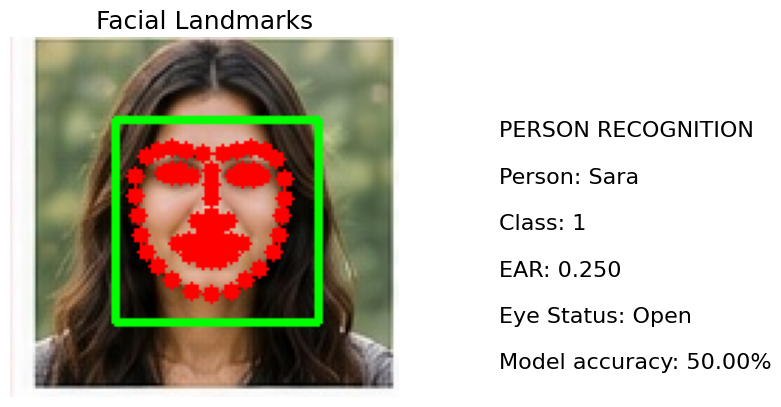

In [59]:
# Convert BGR to RGB
image_rgb = cv2.cvtColor(
    display_image,
    cv2.COLOR_BGR2RGB
)

# Create figure
fig = plt.figure(figsize=(8, 4))

# Create two areas:
# left = image
# right = information
ax_image = fig.add_axes([0.02, 0.05, 0.65, 0.90])
ax_info = fig.add_axes([0.70, 0.20, 0.28, 0.60])

# -----------------------------
# DISPLAY IMAGE
# -----------------------------

ax_image.imshow(image_rgb)

ax_image.set_title(
    "Facial Landmarks",
    fontsize=18
)

ax_image.axis("off")


# -----------------------------
# INFORMATION PANEL
# -----------------------------

ax_info.axis("off")

information = (
    f"PERSON RECOGNITION\n"
    f"\n"
    f"Person: {person_name}\n"
    f"\n"
    f"Class: {prediction}\n"
    f"\n"
    f"EAR: {EAR:.3f}\n"
    f"\n"
    f"Eye Status: {eye_status}\n"
    f"\n"
    f"Model accuracy: {accuracy * 100:.2f}%"
)

ax_info.text(
    0.05,
    0.90,
    information,
    fontsize=16,
    verticalalignment="top",
    transform=ax_info.transAxes
)

plt.show()